# Individual-Level Model Fitting

## Goal
Determine which computational model best explains each individual player's role choices,
using a posterior distribution over models (not hard assignment).
Then recombine per-player model assignments to predict team-level behavior.

## Approach
1. **Load data** at the per-player level (using `shared.data_loading`)
2. **Define models** with aggregate-fitted parameters (from model_benchmarks experiment)
3. **Per-player log-likelihood**: For each player across all their rounds/stages, compute
   P(observed role | model) under each model
4. **Posterior over models**: Using uniform prior over models, compute
   P(model | player's data) ∝ P(data | model) × P(model)
5. **Visualize**: Distribution of model assignments across players, relationship to
   player stats, stat-optimal adherence, etc.
6. **Team-level recombination**: For each team-round, use each player's best (or posterior-weighted)
   model to predict their role, combine into team combo prediction, evaluate vs aggregate approach

## Models (with aggregate-fitted parameters)
- **Random**: Uniform 1/3 per role
- **Random Walk** (ε=0.38): Stick to previous role with prob 1-ε
- **Optimal**: Always choose highest-value role
- **Bayesian-Value** (τ_prior=5.6, τ_softmax=0.1, ε=0.2): Softmax over expected values
- **Bayesian-Belief** (τ_prior=2.0, ε=0.5): Marginalize posterior for role probs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict

# Shared package
from shared import EXPORTS_DIR, DATA_ROOT
from shared.constants import (
    F, T, M,
    ROLE_NAMES, ROLE_SHORT, ROLE_CHAR_TO_IDX, GAME_ROLE_TO_IDX,
    ALL_ROLE_COMBOS, MAX_STAGES, TURNS_PER_STAGE,
    ROLE_COMBO_TO_ENV_NUM,
)
from shared.parsing import canonical_combo, get_canonical_combos
from shared.inference import (
    utility_based_prior, uniform_prior,
    bayesian_update, action_prob, preferred_action, game_step,
    softmax_role_dist, combo_marginal,
    ATTACK, DEFEND, HEAL,
)
from shared.evaluation import (
    run_predictions, compute_pearson, compute_log_likelihood, extract_metrics,
)
from shared.data_loading import load_all_exports, to_dataframe
from shared.env_loading import make_env_loader

print("Imports OK")

Imports OK


## Step 1: Load Data

Load per-player records from March 6 + March 18 exports (human rounds only).
Build team-round records with env configs attached, plus participant ID mapping.

In [2]:
# Load per-player records (human rounds only, no dropout games)
DATA_DIRS = [
    EXPORTS_DIR / 'bayesian-role-specialization-2026-03-06-09-54-19',
    EXPORTS_DIR / 'bayesian-role-specialization-2026-03-18-15-47-09',
]
player_records = load_all_exports(data_dirs=DATA_DIRS, include_bot_rounds=False, include_dropout_games=False)
df = to_dataframe(player_records)
print(f"\n{len(df)} player-rounds, {df['participant_id'].nunique()} unique participants")
print(f"Games: {df['game_id'].nunique()}")
print(f"Round types: {df['round_type'].value_counts().to_dict()}")

Loaded bayesian-role-specialization-2026-03-06-09-54-19: 54 player-rounds
Loaded bayesian-role-specialization-2026-03-18-15-47-09: 144 player-rounds
Total: 198 player-rounds from 2 exports

198 player-rounds, 33 unique participants
Games: 11
Round types: {'human': 198}


In [3]:
# Build team-round records from per-player data
# Group by (game_id, round_number) to get teams of 3
env_loader = make_env_loader()

team_records = []
grouped = df.groupby(['game_id', 'round_number'])

for (game_id, round_num), group in grouped:
    if len(group) != 3:
        print(f"WARNING: {game_id} R{round_num} has {len(group)} players, skipping")
        continue
    
    # Sort by player_id (position 0, 1, 2)
    group = group.sort_values('player_id')
    players = group.to_dict('records')
    
    # Extract participant IDs for each position
    participant_ids = [p['participant_id'] for p in players]
    
    # Build stage_roles combo strings from per-player stage data
    # Each player has 'roles' list (one per stage) and 'role_idxs' list
    n_stages = min(p['n_stages'] for p in players)
    stage_roles = []
    for s in range(n_stages):
        combo = ''.join(ROLE_SHORT[players[pos]['role_idxs'][s]] for pos in range(3))
        stage_roles.append(combo)
    
    if not stage_roles:
        continue
    
    # Get config info from first player (same for all in the team)
    config = players[0]['config']
    optimal_roles_idx = config.get('optimalRoles', [])
    role_combo = ''.join(ROLE_SHORT[ri] for ri in optimal_roles_idx)
    stat_profile = players[0]['stat_profile_id']
    lds = [int(c) for c in players[0]['enemy_intent_sequence']]
    
    # Load env config (values.npy + game params) by role combo
    env_config = env_loader(role_combo=role_combo)
    
    team_records.append({
        'game_id': game_id,
        'round_number': round_num,
        'env_id': f"{stat_profile}_{role_combo}",  # match benchmarks format
        'stat_profile': stat_profile,
        'optimal_roles': role_combo,
        'lds': lds,
        'stage_roles': stage_roles,
        'env_config': env_config,
        'participant_ids': participant_ids,  # [pos0, pos1, pos2]
    })

print(f"Built {len(team_records)} team-rounds")
print(f"Environments: {sorted(set(r['env_id'] for r in team_records))}")

Built 66 team-rounds
Environments: ['114_222_222_MFF', '222_222_222_FFF', '411_141_114_FFM', '411_141_114_FTF', '411_141_114_FTM', '411_222_222_FMM']


In [4]:
# Check participant coverage
all_pids = set()
pid_stage_counts = defaultdict(int)
for rec in team_records:
    for pos in range(3):
        pid = rec['participant_ids'][pos]
        all_pids.add(pid)
        pid_stage_counts[pid] += len(rec['stage_roles'])

print(f"Unique participants: {len(all_pids)}")
counts = sorted(pid_stage_counts.values())
print(f"Stages per participant: min={min(counts)}, max={max(counts)}, median={np.median(counts):.0f}, mean={np.mean(counts):.1f}")

Unique participants: 33
Stages per participant: min=19, max=25, median=21, mean=21.3


## Step 2: Define Models (Per-Player Marginals)

Each model function takes a team-round record and returns a list (one per stage) of per-player marginals:
`list[list[np.array]]` — `stage_marginals[s][player_i]` is a length-3 probability vector over roles.

In [5]:
def marginals_from_combo_dist(combo_dist):
    """Extract per-player marginals from a combo distribution."""
    marginals = [np.zeros(3) for _ in range(3)]
    for combo, prob in combo_dist.items():
        for i, c in enumerate(combo):
            marginals[i][ROLE_CHAR_TO_IDX[c]] += prob
    return marginals


# --- Model 1: Random ---
def model_random(record):
    uniform = np.ones(3) / 3.0
    return [[uniform.copy() for _ in range(3)] for _ in record['stage_roles']]


# --- Model 2: Random Walk (ε=0.38) ---
def make_model_random_walk(eps=0.38):
    def model(record):
        stage_marginals = []
        for s, combo in enumerate(record['stage_roles']):
            if s == 0:
                stage_marginals.append([np.ones(3) / 3.0 for _ in range(3)])
            else:
                prev_combo = record['stage_roles'][s - 1]
                player_margs = []
                for i in range(3):
                    marg = np.full(3, eps / 2.0)
                    prev_role_idx = ROLE_CHAR_TO_IDX[prev_combo[i]]
                    marg[prev_role_idx] = 1.0 - eps
                    player_margs.append(marg)
                stage_marginals.append(player_margs)
        return stage_marginals
    return model


# --- Model 3: Optimal ---
def model_optimal(record):
    env = record['env_config']
    values = env['values']
    lds = record['lds']
    team_max_hp = int(env['team_max_hp'])
    enemy_max_hp = int(env['enemy_max_hp'])
    
    stage_marginals = []
    for s in range(len(record['stage_roles'])):
        turn_idx = s * TURNS_PER_STAGE
        intent = lds[turn_idx] if turn_idx < len(lds) else 0
        thp = min(team_max_hp, values.shape[2] - 1)
        ehp = min(enemy_max_hp, values.shape[3] - 1)
        
        # Find optimal combo(s)
        vals = []
        for combo in ALL_ROLE_COMBOS:
            idx = ROLE_CHAR_TO_IDX[combo[0]] * 9 + ROLE_CHAR_TO_IDX[combo[1]] * 3 + ROLE_CHAR_TO_IDX[combo[2]]
            vals.append(float(values[idx, intent, thp, ehp]))
        max_val = max(vals)
        
        combo_dist = {}
        optimal_combos = [c for c, v in zip(ALL_ROLE_COMBOS, vals) if abs(v - max_val) < 1e-8]
        for c in ALL_ROLE_COMBOS:
            combo_dist[c] = (1.0 / len(optimal_combos)) if c in optimal_combos else 0.0
        
        stage_marginals.append(marginals_from_combo_dist(combo_dist))
    return stage_marginals


# --- Model 4: Bayesian-Value (teacher-forced) ---
def make_model_bayesian_value(tau_prior=5.6, tau_softmax=0.1, epsilon=0.2):
    def model(record):
        env = record['env_config']
        values = env['values']
        player_stats = env['player_stats']
        boss_damage = env['boss_damage']
        team_max_hp, enemy_max_hp = env['team_max_hp'], env['enemy_max_hp']
        
        team_hp, enemy_hp = float(team_max_hp), float(enemy_max_hp)
        prior = utility_based_prior(player_stats, tau=tau_prior)
        stage_marginals = []
        turn_idx = 0
        
        for human_combo in record['stage_roles']:
            if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0:
                break
            
            intent = record['lds'][turn_idx]
            thp = int(min(max(0, team_hp), team_max_hp))
            ehp = int(min(max(0, enemy_hp), enemy_max_hp))
            
            per_agent = [softmax_role_dist(i, intent, thp, ehp, prior, values, tau_softmax) for i in range(3)]
            stage_marginals.append(per_agent)
            
            # Teacher-force: advance game with actual human roles
            human_roles = [ROLE_CHAR_TO_IDX[c] for c in human_combo]
            for _ in range(TURNS_PER_STAGE):
                if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0:
                    break
                intent = record['lds'][turn_idx]
                actions = [preferred_action(human_roles[i], intent, team_hp, team_max_hp) for i in range(3)]
                prior = bayesian_update(prior, actions, intent, team_hp, team_max_hp, epsilon)
                team_hp, enemy_hp = game_step(intent, team_hp, enemy_hp, actions, player_stats, boss_damage, team_max_hp)
                turn_idx += 1
        
        return stage_marginals
    return model


# --- Model 5: Bayesian-Belief (teacher-forced) ---
def make_model_bayesian_belief(tau_prior=2.0, epsilon=0.5):
    def model(record):
        env = record['env_config']
        player_stats = env['player_stats']
        boss_damage = env['boss_damage']
        team_max_hp, enemy_max_hp = env['team_max_hp'], env['enemy_max_hp']
        
        team_hp, enemy_hp = float(team_max_hp), float(enemy_max_hp)
        prior = utility_based_prior(player_stats, tau=tau_prior)
        stage_marginals = []
        turn_idx = 0
        
        for human_combo in record['stage_roles']:
            if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0:
                break
            
            # Marginalize posterior for each player
            per_agent = []
            for i in range(3):
                marg = np.sum(prior, axis=tuple(j for j in range(3) if j != i))
                total = marg.sum()
                per_agent.append(marg / total if total > 0 else np.ones(3) / 3)
            stage_marginals.append(per_agent)
            
            # Teacher-force
            human_roles = [ROLE_CHAR_TO_IDX[c] for c in human_combo]
            for _ in range(TURNS_PER_STAGE):
                if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0:
                    break
                intent = record['lds'][turn_idx]
                actions = [preferred_action(human_roles[i], intent, team_hp, team_max_hp) for i in range(3)]
                prior = bayesian_update(prior, actions, intent, team_hp, team_max_hp, epsilon)
                team_hp, enemy_hp = game_step(intent, team_hp, enemy_hp, actions, player_stats, boss_damage, team_max_hp)
                turn_idx += 1
        
        return stage_marginals
    return model


# Instantiate all models
MODELS = {
    'Random': model_random,
    'Random Walk': make_model_random_walk(eps=0.38),
    'Optimal': model_optimal,
    'Bayesian-Value': make_model_bayesian_value(tau_prior=5.6, tau_softmax=0.1, epsilon=0.2),
    'Bayesian-Belief': make_model_bayesian_belief(tau_prior=2.0, epsilon=0.5),
}

# Quick sanity check: run one record
test_rec = team_records[0]
for name, fn in MODELS.items():
    margs = fn(test_rec)
    print(f"{name}: {len(margs)} stages, player 0 stage 0 = {margs[0][0].round(3)}")

Random: 3 stages, player 0 stage 0 = [0.333 0.333 0.333]
Random Walk: 3 stages, player 0 stage 0 = [0.333 0.333 0.333]
Optimal: 3 stages, player 0 stage 0 = [1. 0. 0.]
Bayesian-Value: 3 stages, player 0 stage 0 = [1. 0. 0.]
Bayesian-Belief: 3 stages, player 0 stage 0 = [0.691 0.154 0.154]


## Step 3: Per-Player Log-Likelihood

All model predictions are mixed with a **lapse rate** (λ=0.05): `P(role) = (1-λ)·P_model + λ·(1/3)`.
This prevents models with concentrated predictions (Optimal, Bayesian-Value) from being catastrophically
penalized when a player deviates — without it, a single "wrong" choice gives log(~0) ≈ -46, making
those models get zero posterior for every player.

In [6]:
LAPSE_RATE = 0.05
UNIFORM = np.ones(3) / 3.0
model_names = list(MODELS.keys())

def apply_lapse(marginal, lapse=LAPSE_RATE):
    """Mix model prediction with uniform: (1-λ)*model + λ*uniform"""
    return (1.0 - lapse) * marginal + lapse * UNIFORM

# Accumulate per-player log-likelihoods
player_ll = {name: defaultdict(float) for name in MODELS}
player_n_stages = defaultdict(int)

for rec in team_records:
    model_outputs = {name: fn(rec) for name, fn in MODELS.items()}
    for s, human_combo in enumerate(rec['stage_roles']):
        for pos in range(3):
            pid = rec['participant_ids'][pos]
            actual_role_idx = ROLE_CHAR_TO_IDX[human_combo[pos]]
            player_n_stages[pid] += 1
            for name in MODELS:
                margs = model_outputs[name]
                if s < len(margs):
                    prob = apply_lapse(margs[s][pos])[actual_role_idx]
                else:
                    prob = 1.0 / 3.0
                player_ll[name][pid] += np.log(max(prob, 1e-20))

# Build DataFrame
ll_rows = []
for pid in sorted(all_pids):
    row = {'participant_id': pid, 'n_stages': player_n_stages[pid]}
    for name in MODELS:
        row[f'll_{name}'] = player_ll[name][pid]
    ll_rows.append(row)
ll_df = pd.DataFrame(ll_rows)

print(f"Per-player log-likelihoods (λ={LAPSE_RATE}):")
print(ll_df[['participant_id', 'n_stages'] + [f'll_{n}' for n in MODELS]].head(5).to_string(
    float_format='{:.2f}'.format))

Per-player log-likelihoods (λ=0.05):
               participant_id  n_stages  ll_Random  ll_Random Walk  ll_Optimal  ll_Bayesian-Value  ll_Bayesian-Belief
0  01KK14VYMQG76JJB7WRNQAG8JS        25     -27.47          -27.34      -50.76             -44.72              -26.45
1  01KK14YMHKVJNXZC5CBQ01234T        21     -23.07          -17.48      -22.20             -27.93              -11.10
2  01KK14YZGGKW3QSWB438DNTCY8        21     -23.07          -26.46      -64.27             -61.46              -26.30
3  01KK151DEMDQP6895Y4Q9YRAMC        25     -27.47          -26.22      -55.60             -45.17              -27.04
4  01KK152ABN78TH8X8TDYYVA3QZ        25     -27.47          -20.61      -72.40             -67.54              -22.42


## Step 4: Posterior Over Models

Uniform prior over 5 models. Posterior ∝ exp(log-likelihood).

In [7]:
posterior_rows = []
for _, row in ll_df.iterrows():
    pid = row['participant_id']
    lls = np.array([row[f'll_{name}'] for name in model_names])
    log_post = lls - lls.max()  # numerical stability
    post = np.exp(log_post)
    post /= post.sum()
    
    entry = {'participant_id': pid, 'n_stages': row['n_stages']}
    for i, name in enumerate(model_names):
        entry[f'P({name})'] = post[i]
    entry['dominant_model'] = model_names[np.argmax(post)]
    posterior_rows.append(entry)

post_df = pd.DataFrame(posterior_rows)

print("=== Posterior Over Models ===\n")
post_cols = [f'P({name})' for name in model_names]
print(post_df[['participant_id', 'n_stages', 'dominant_model'] + post_cols].to_string(
    float_format='{:.3f}'.format, index=False))
print(f"\n=== Dominant Model Counts ===")
print(post_df['dominant_model'].value_counts().to_string())

=== Posterior Over Models ===

            participant_id  n_stages  dominant_model  P(Random)  P(Random Walk)  P(Optimal)  P(Bayesian-Value)  P(Bayesian-Belief)
01KK14VYMQG76JJB7WRNQAG8JS        25 Bayesian-Belief      0.204           0.231       0.000              0.000               0.564
01KK14YMHKVJNXZC5CBQ01234T        21 Bayesian-Belief      0.000           0.002       0.000              0.000               0.998
01KK14YZGGKW3QSWB438DNTCY8        21          Random      0.932           0.031       0.000              0.000               0.037
01KK151DEMDQP6895Y4Q9YRAMC        25     Random Walk      0.167           0.579       0.000              0.000               0.254
01KK152ABN78TH8X8TDYYVA3QZ        25     Random Walk      0.001           0.859       0.000              0.000               0.140
01KK154GTYND381DYD3WMWK0V7        23 Bayesian-Belief      0.098           0.103       0.000              0.000               0.800
01KK156BWNV8GZHEYKH36YWK8X        21 Bayesian-Belief

## Step 5: Visualizations

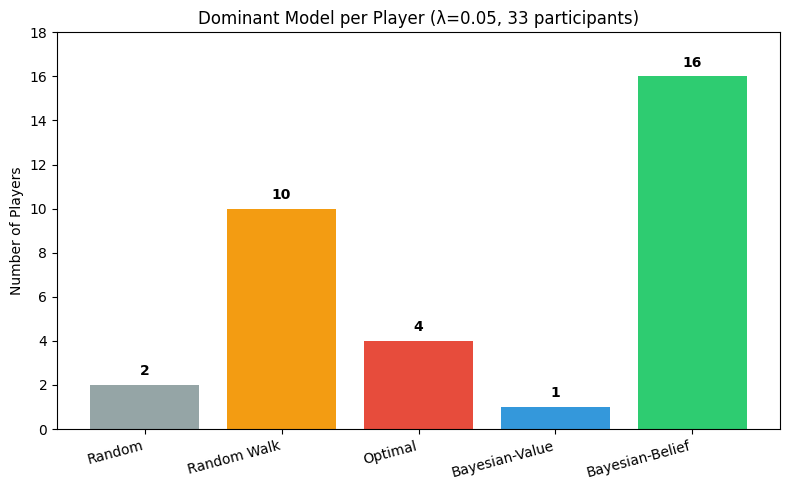

In [8]:
# --- Bar chart: dominant model per player ---
fig, ax = plt.subplots(figsize=(8, 5))
counts = post_df['dominant_model'].value_counts().reindex(model_names, fill_value=0)
colors = ['#95a5a6', '#f39c12', '#e74c3c', '#3498db', '#2ecc71']
bars = ax.bar(counts.index, counts.values, color=colors)
ax.set_ylabel('Number of Players')
ax.set_title(f'Dominant Model per Player (λ={LAPSE_RATE}, 33 participants)')
for bar, val in zip(bars, counts.values):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(val), ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0, max(counts.values) + 2)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

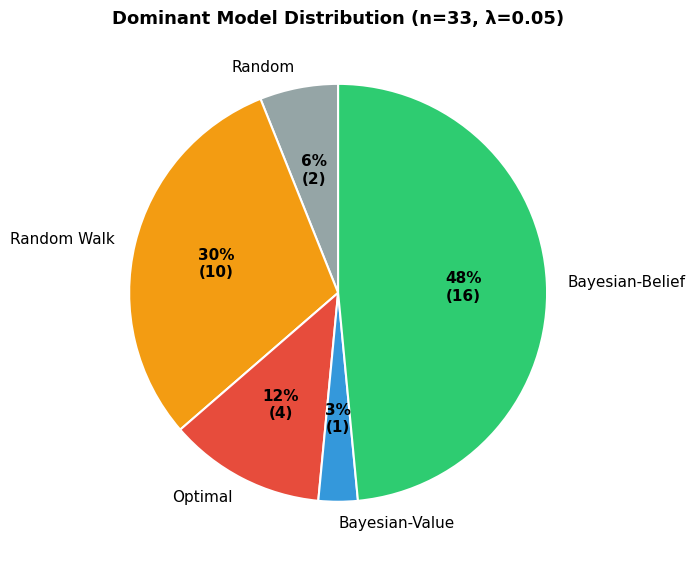

In [9]:
# --- Pie chart: dominant model distribution ---
model_colors = {'Random': '#95a5a6', 'Random Walk': '#f39c12', 'Optimal': '#e74c3c',
                'Bayesian-Value': '#3498db', 'Bayesian-Belief': '#2ecc71'}

counts = post_df['dominant_model'].value_counts().reindex(model_names, fill_value=0)
counts = counts[counts > 0]

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    counts.values, labels=counts.index,
    colors=[model_colors[m] for m in counts.index],
    autopct=lambda pct: f'{pct:.0f}%\n({int(round(pct/100*33))})',
    startangle=90, textprops={'fontsize': 11},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
for at in autotexts:
    at.set_fontweight('bold')
ax.set_title(f'Dominant Model Distribution (n=33, λ={LAPSE_RATE})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

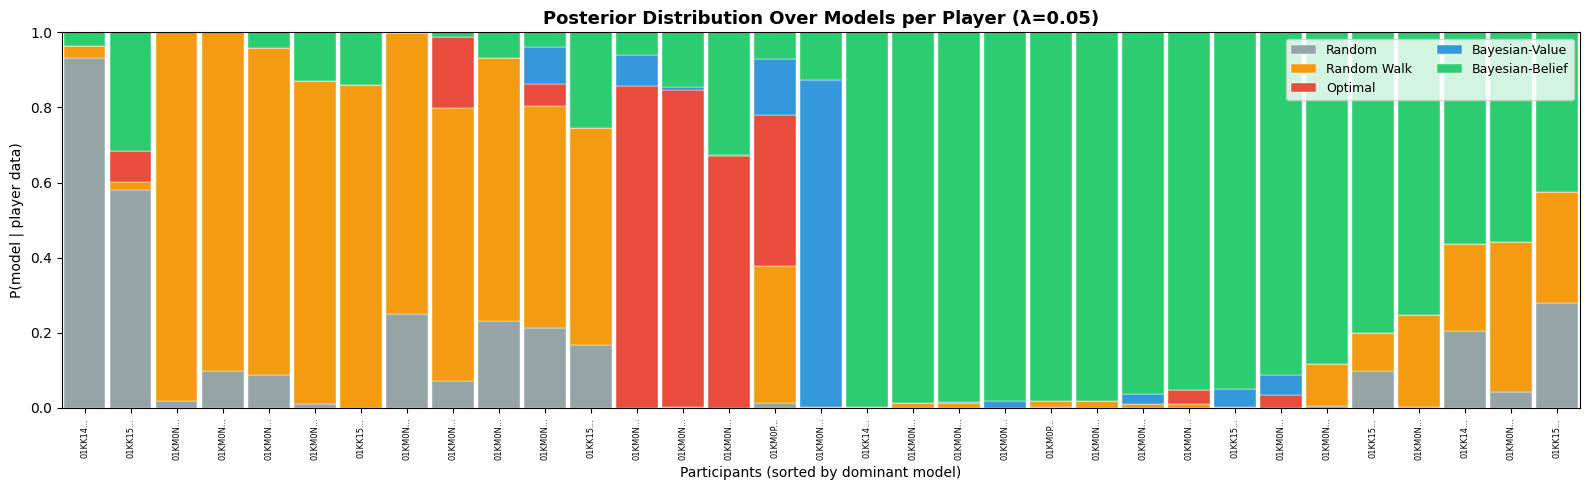

In [10]:
# --- Stacked bar: full posterior distribution per player ---
model_colors_list = [model_colors[m] for m in model_names]

df_plot = post_df.copy()
model_order = {name: i for i, name in enumerate(model_names)}
df_plot['sort_model'] = df_plot['dominant_model'].map(model_order)
df_plot['sort_weight'] = df_plot.apply(lambda r: r[f'P({r["dominant_model"]})'], axis=1)
df_plot = df_plot.sort_values(['sort_model', 'sort_weight'], ascending=[True, False]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16, 5))
x = np.arange(len(df_plot))
bottoms = np.zeros(len(df_plot))

for i, name in enumerate(model_names):
    vals = df_plot[f'P({name})'].values
    ax.bar(x, vals, bottom=bottoms, color=model_colors_list[i], label=name, width=0.9,
           edgecolor='white', linewidth=0.3)
    bottoms += vals

ax.set_xlim(-0.5, len(df_plot) - 0.5)
ax.set_ylim(0, 1)
ax.set_xlabel('Participants (sorted by dominant model)')
ax.set_ylabel('P(model | player data)')
ax.set_title(f'Posterior Distribution Over Models per Player (λ={LAPSE_RATE})', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'{pid[:6]}...' for pid in df_plot['participant_id']], rotation=90, fontsize=6)
ax.legend(loc='upper right', fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

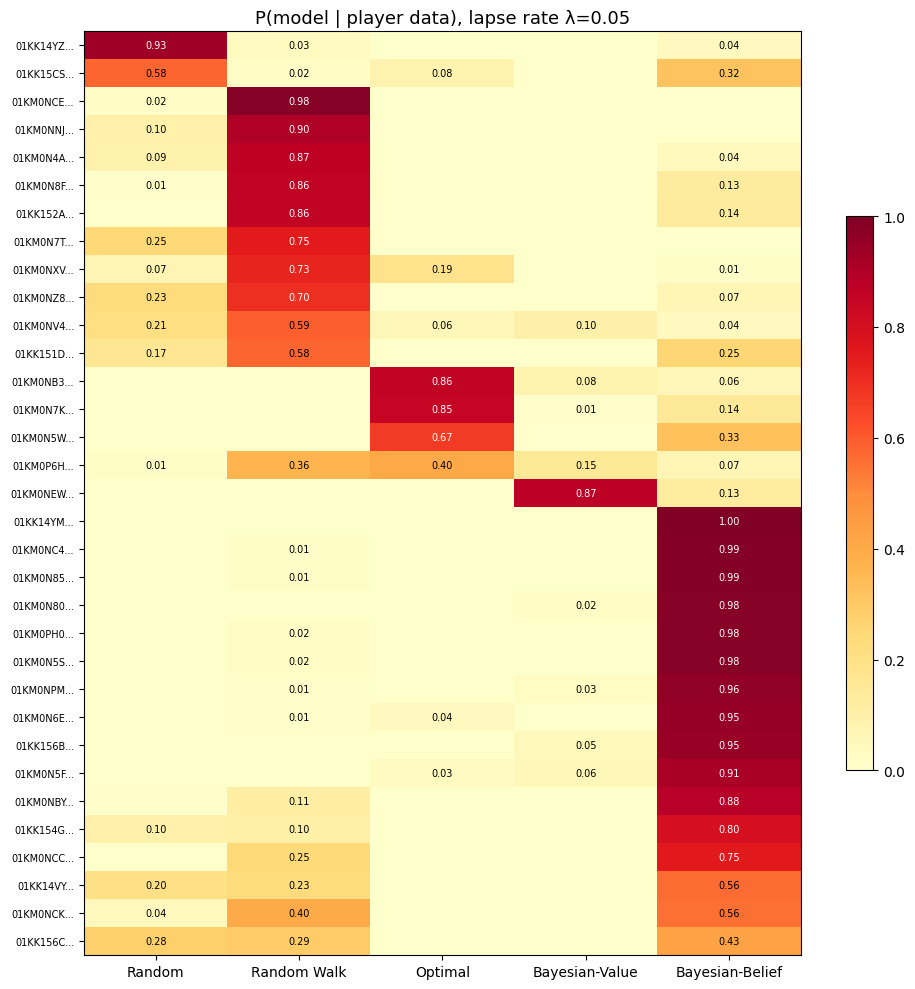

In [11]:
# --- Heatmap: posterior distribution over models for each player ---
post_df_sorted = post_df.copy()
model_order = {name: i for i, name in enumerate(model_names)}
post_df_sorted['sort_key'] = post_df_sorted['dominant_model'].map(model_order)
post_df_sorted['dominant_weight'] = post_df_sorted.apply(
    lambda r: r[f'P({r["dominant_model"]})'], axis=1)
post_df_sorted = post_df_sorted.sort_values(['sort_key', 'dominant_weight'], ascending=[True, False])

heatmap_data = post_df_sorted[[f'P({name})' for name in model_names]].values
player_labels = [f"{pid[:8]}..." for pid in post_df_sorted['participant_id']]

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(heatmap_data, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(len(model_names)))
ax.set_xticklabels(model_names, fontsize=10)
ax.set_yticks(range(len(player_labels)))
ax.set_yticklabels(player_labels, fontsize=7)
ax.set_title(f'P(model | player data), lapse rate λ={LAPSE_RATE}', fontsize=13)
plt.colorbar(im, ax=ax, shrink=0.6)

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        val = heatmap_data[i, j]
        if val > 0.005:
            color = 'white' if val > 0.6 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7, color=color)

plt.tight_layout()
plt.show()

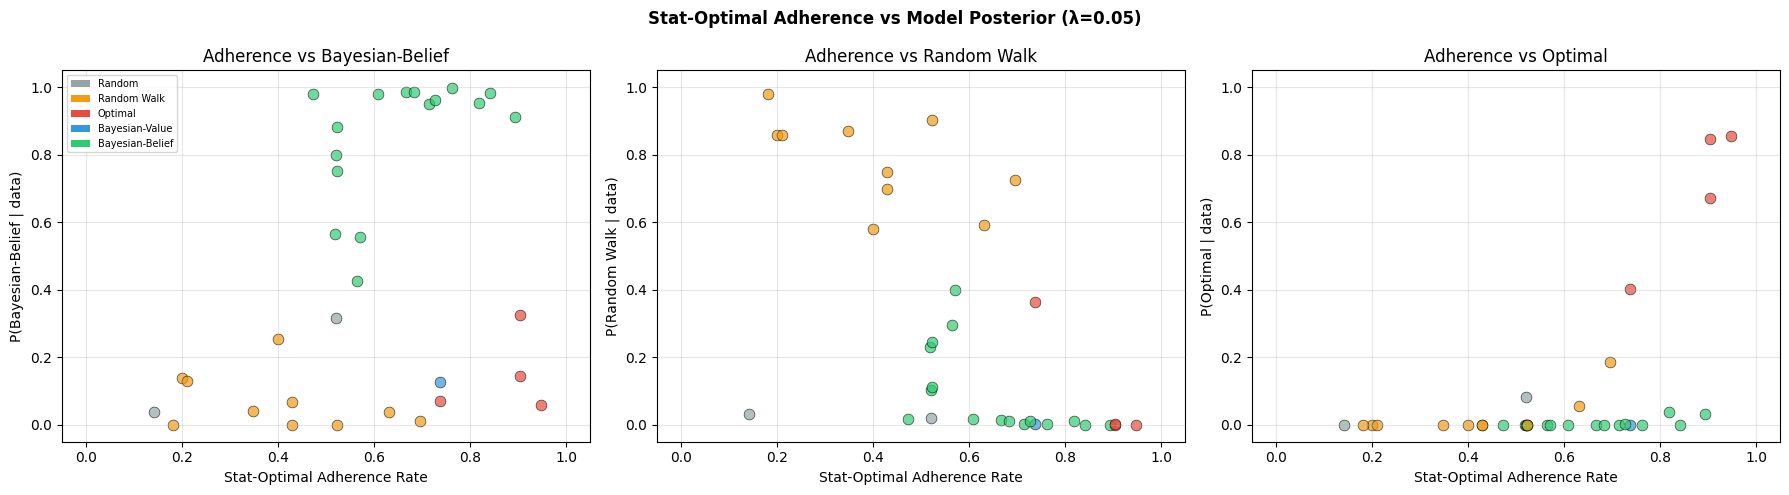

Adherence vs P(Bayesian-Belief): r=0.371, p=0.0338
Adherence vs P(Random Walk): r=-0.638, p=0.0001
Adherence vs P(Optimal): r=0.536, p=0.0013


In [12]:
# Compute stat-optimal adherence per participant
pid_stat_optimal_count = defaultdict(int)
pid_total_stages = defaultdict(int)
for rec in team_records:
    optimal_combo = rec['optimal_roles']
    for s, combo in enumerate(rec['stage_roles']):
        for pos in range(3):
            pid = rec['participant_ids'][pos]
            pid_total_stages[pid] += 1
            if combo[pos] == optimal_combo[pos]:
                pid_stat_optimal_count[pid] += 1

# Scatter: adherence vs model posteriors
scatter_data = []
for _, row in post_df.iterrows():
    pid = row['participant_id']
    adherence = pid_stat_optimal_count[pid] / pid_total_stages[pid]
    scatter_data.append({
        'adherence': adherence, 'dominant': row['dominant_model'],
        **{f'P({name})': row[f'P({name})'] for name in model_names},
    })
scatter_df = pd.DataFrame(scatter_data)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
color_map = {'Random': '#95a5a6', 'Random Walk': '#f39c12', 'Optimal': '#e74c3c',
             'Bayesian-Value': '#3498db', 'Bayesian-Belief': '#2ecc71'}

for ax, model in zip(axes, ['Bayesian-Belief', 'Random Walk', 'Optimal']):
    for _, row in scatter_df.iterrows():
        ax.scatter(row['adherence'], row[f'P({model})'],
                   c=color_map[row['dominant']], s=60, alpha=0.7, edgecolors='k', linewidths=0.5)
    ax.set_xlabel('Stat-Optimal Adherence Rate')
    ax.set_ylabel(f'P({model} | data)')
    ax.set_title(f'Adherence vs {model}')
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05); ax.grid(True, alpha=0.3)

from matplotlib.patches import Patch
legend_els = [Patch(facecolor=color_map[m], label=m) for m in model_names if post_df['dominant_model'].eq(m).any()]
axes[0].legend(handles=legend_els, loc='upper left', fontsize=7)
plt.suptitle(f'Stat-Optimal Adherence vs Model Posterior (λ={LAPSE_RATE})', fontweight='bold')
plt.tight_layout()
plt.show()

from scipy.stats import pearsonr
for model in ['Bayesian-Belief', 'Random Walk', 'Optimal']:
    r, p = pearsonr(scatter_df['adherence'], scatter_df[f'P({model})'])
    print(f"Adherence vs P({model}): r={r:.3f}, p={p:.4f}")

In [13]:
# Per-player metadata
pid_stats = {}
pid_stat_profile = {}
for _, row in df.drop_duplicates('participant_id').iterrows():
    pid = row['participant_id']
    stats = row['player_stats']
    if isinstance(stats, dict):
        pid_stats[pid] = stats
        pid_stat_profile[pid] = f"{stats.get('STR','?')}/{stats.get('DEF','?')}/{stats.get('SUP','?')}"

post_df['stat_profile'] = post_df['participant_id'].map(pid_stat_profile)

# Stat profile vs dominant model
cross = pd.crosstab(post_df['stat_profile'], post_df['dominant_model']).reindex(columns=model_names, fill_value=0)
print("=== Dominant Model by Stat Profile ===\n")
print(cross.to_string())

# Per-player summary table
print("\n=== Per-Player Summary ===\n")
rows = []
for _, row in post_df.iterrows():
    pid = row['participant_id']
    adherence = pid_stat_optimal_count[pid] / pid_total_stages[pid]
    rows.append({
        'PID': pid[:10] + '...', 'Stats': pid_stat_profile.get(pid, '?'),
        'N': row['n_stages'], 'Adh': f"{adherence:.0%}", 'Best': row['dominant_model'],
        'P(R)': f"{row['P(Random)']:.2f}", 'P(RW)': f"{row['P(Random Walk)']:.2f}",
        'P(Opt)': f"{row['P(Optimal)']:.2f}", 'P(BV)': f"{row['P(Bayesian-Value)']:.2f}",
        'P(BB)': f"{row['P(Bayesian-Belief)']:.2f}",
    })
print(pd.DataFrame(rows).to_string(index=False))

=== Dominant Model by Stat Profile ===

dominant_model  Random  Random Walk  Optimal  Bayesian-Value  Bayesian-Belief
stat_profile                                                                 
1/1/4                0            0        1               1                4
1/4/1                1            2        0               0                2
2/2/2                1            7        1               0                5
4/1/1                0            1        2               0                5

=== Per-Player Summary ===

          PID Stats  N Adh            Best P(R) P(RW) P(Opt) P(BV) P(BB)
01KK14VYMQ... 4/1/1 25 52% Bayesian-Belief 0.20  0.23   0.00  0.00  0.56
01KK14YMHK... 4/1/1 21 76% Bayesian-Belief 0.00  0.00   0.00  0.00  1.00
01KK14YZGG... 1/4/1 21 14%          Random 0.93  0.03   0.00  0.00  0.04
01KK151DEM... 2/2/2 25 40%     Random Walk 0.17  0.58   0.00  0.00  0.25
01KK152ABN... 2/2/2 25 20%     Random Walk 0.00  0.86   0.00  0.00  0.14
01KK154GTY... 2/2/2 23 52

## Step 6: Team-Level Recombination

Use each player's posterior-weighted model mixture to predict their role, combine into team combo predictions.

In [14]:
# --- Step 6: Team-level recombination ---
pid_posteriors = {}
for _, row in post_df.iterrows():
    pid_posteriors[row['participant_id']] = {name: row[f'P({name})'] for name in model_names}

def make_individual_predict(posteriors_dict):
    def predict(record):
        model_outputs = {name: fn(record) for name, fn in MODELS.items()}
        preds = []
        for s, human_combo in enumerate(record['stage_roles']):
            player_marginals = []
            for pos in range(3):
                pid = record['participant_ids'][pos]
                weights = posteriors_dict[pid]
                mixture = np.zeros(3)
                for name in model_names:
                    if s < len(model_outputs[name]):
                        mixture += weights[name] * model_outputs[name][s][pos]
                    else:
                        mixture += weights[name] * np.ones(3) / 3.0
                mixture = np.maximum(mixture, 1e-20)
                mixture /= mixture.sum()
                player_marginals.append(mixture)
            predicted_dist = {}
            for r0 in range(3):
                for r1 in range(3):
                    for r2 in range(3):
                        combo = ROLE_SHORT[r0] + ROLE_SHORT[r1] + ROLE_SHORT[r2]
                        predicted_dist[combo] = float(
                            player_marginals[0][r0] * player_marginals[1][r1] * player_marginals[2][r2])
            preds.append({
                'predicted_dist': predicted_dist,
                'human_combo': human_combo,
                'model_marginal': np.mean(player_marginals, axis=0),
            })
        return preds
    return predict

# Run individual-fitted model
indiv_results = run_predictions(team_records, make_individual_predict(pid_posteriors))
indiv_metrics = extract_metrics(compute_pearson(indiv_results))

# Run aggregate baselines for comparison
def make_aggregate_predict(model_fn):
    def predict(record):
        margs = model_fn(record)
        preds = []
        for s, human_combo in enumerate(record['stage_roles']):
            if s >= len(margs): break
            predicted_dist = {}
            for r0 in range(3):
                for r1 in range(3):
                    for r2 in range(3):
                        combo = ROLE_SHORT[r0] + ROLE_SHORT[r1] + ROLE_SHORT[r2]
                        predicted_dist[combo] = float(margs[s][0][r0] * margs[s][1][r1] * margs[s][2][r2])
            preds.append({
                'predicted_dist': predicted_dist,
                'human_combo': human_combo,
                'model_marginal': np.mean(margs[s], axis=0),
            })
        return preds
    return predict

bb_metrics = extract_metrics(compute_pearson(run_predictions(team_records, make_aggregate_predict(MODELS['Bayesian-Belief']))))
rw_metrics = extract_metrics(compute_pearson(run_predictions(team_records, make_aggregate_predict(MODELS['Random Walk']))))
rand_metrics = extract_metrics(compute_pearson(run_predictions(team_records, make_aggregate_predict(MODELS['Random']))))

print("=== Team-Level Prediction Comparison ===\n")
comparison = pd.DataFrame([
    {'Model': 'Individual-Fitted Mixture', 'combo_r': indiv_metrics['combo_r'], 'marg_r': indiv_metrics['marg_r']},
    {'Model': 'Aggregate Bayesian-Belief', 'combo_r': bb_metrics['combo_r'], 'marg_r': bb_metrics['marg_r']},
    {'Model': 'Aggregate Random Walk', 'combo_r': rw_metrics['combo_r'], 'marg_r': rw_metrics['marg_r']},
    {'Model': 'Random', 'combo_r': rand_metrics['combo_r'], 'marg_r': rand_metrics['marg_r']},
]).set_index('Model')
print(comparison.to_string(float_format='{:.4f}'.format))
print(f"\nImprovement over best aggregate (BB): combo_r +{indiv_metrics['combo_r'] - bb_metrics['combo_r']:.4f}, marg_r +{indiv_metrics['marg_r'] - bb_metrics['marg_r']:.4f}")

=== Team-Level Prediction Comparison ===

                           combo_r  marg_r
Model                                     
Individual-Fitted Mixture   0.5753  0.5853
Aggregate Bayesian-Belief   0.4732  0.3582
Aggregate Random Walk       0.3855  0.4576
Random                      0.1567 -0.0000

Improvement over best aggregate (BB): combo_r +0.1021, marg_r +0.2270


/Users/jolow/coding/bayesian-role-specialization/analysis/shared/evaluation.py:129: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  r, p = pearsonr(marg_m, marg_h)
/Users/jolow/coding/bayesian-role-specialization/analysis/shared/evaluation.py:126: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(combo_m, combo_h)
/Users/jolow/coding/bayesian-role-specialization/analysis/shared/evaluation.py:129: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(marg_m, marg_h)
/Users/jolow/coding/bayesian-role-specialization/analysis/shared/evaluation.py:143: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  r, p = pearsonr(global_marg_m, global_marg_h)


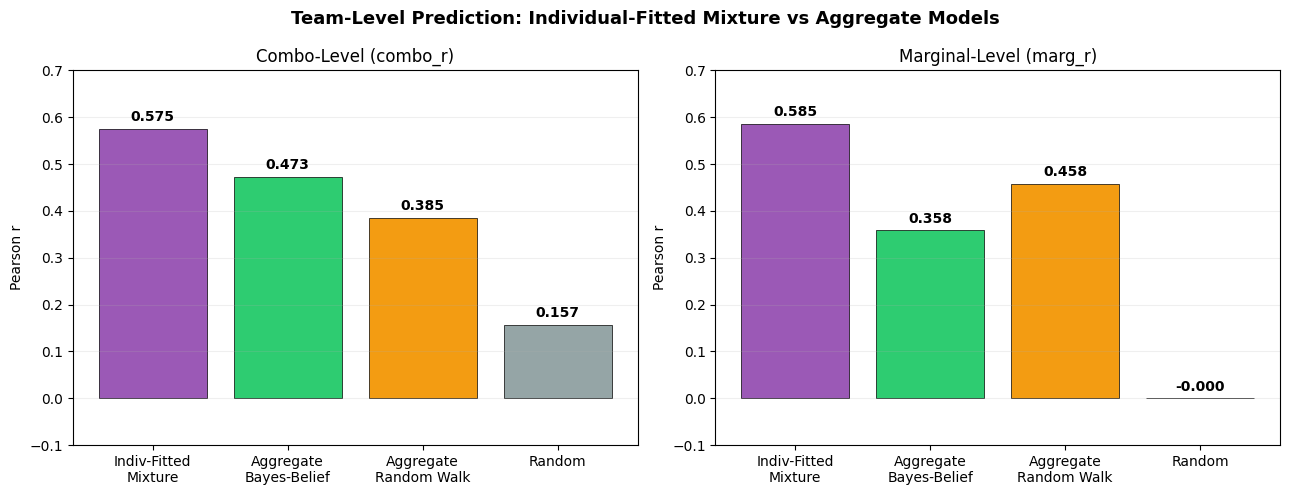

In [15]:
# --- Final comparison bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels = ['Indiv-Fitted\nMixture', 'Aggregate\nBayes-Belief', 'Aggregate\nRandom Walk', 'Random']
combo_vals = [indiv_metrics['combo_r'], bb_metrics['combo_r'], rw_metrics['combo_r'], rand_metrics['combo_r']]
marg_vals = [indiv_metrics['marg_r'], bb_metrics['marg_r'], rw_metrics['marg_r'], rand_metrics['marg_r']]
bar_colors = ['#9b59b6', '#2ecc71', '#f39c12', '#95a5a6']

for ax, vals, title in [(axes[0], combo_vals, 'Combo-Level (combo_r)'),
                         (axes[1], marg_vals, 'Marginal-Level (marg_r)')]:
    bars = ax.bar(labels, vals, color=bar_colors, edgecolor='k', linewidth=0.5)
    ax.set_ylabel('Pearson r')
    ax.set_title(title)
    ax.set_ylim(-0.1, 0.7)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, max(bar.get_height(), 0) + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    ax.grid(True, alpha=0.2, axis='y')

plt.suptitle('Team-Level Prediction: Individual-Fitted Mixture vs Aggregate Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Key Findings

**Lapse rate (λ=0.05):** All model predictions are mixed with uniform: P = (1-λ)·P_model + λ·(1/3). This prevents models that make concentrated predictions (Optimal, Bayesian-Value) from being catastrophically penalized when a player deviates. Without this, a single "wrong" choice gives log(~0) ≈ -46, making Optimal/BV get zero posterior for every player.

**Individual model assignment (with lapse rate):**
- **Bayesian-Belief**: 16/33 players (48%) — dominant for asymmetric stats (4/1/1, 1/1/4) where the prior is informative
- **Random Walk**: 10/33 (30%) — dominant for symmetric stats (2/2/2) where the prior is flat and players tend to persist
- **Optimal**: 4/33 (12%) — highly adherent players (≥90% stat-optimal) who just always pick the "right" role
- **Bayesian-Value**: 1/33 (3%) — rare; similar to Optimal but with belief updating
- **Random**: 2/33 (6%) — players with low adherence and inconsistent patterns

**Correlations with stat-optimal adherence:**
- Adherence ↔ P(Optimal): r=0.54 (high-adherence → Optimal model)
- Adherence ↔ P(Bayesian-Belief): r=0.37 (moderate positive)
- Adherence ↔ P(Random Walk): r=-0.64 (low-adherence → Random Walk)

**Team-level recombination:**
- Individual-fitted mixture: **combo_r=0.575, marg_r=0.585**
- Best aggregate (Bayesian-Belief): combo_r=0.473, marg_r=0.358
- Improvement: **+0.102 combo_r (+22%), +0.227 marg_r (+63%)**

**Interpretation:** Players are heterogeneous in their decision-making strategies. Some are belief-driven (Bayesian-Belief), using stat cues to infer optimal roles. Others are habitual (Random Walk), sticking with previous roles. A few are purely rational (Optimal). Modeling this heterogeneity and recombining per-player predictions yields substantially better team-level accuracy than any single aggregate model.